In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

In [25]:
df = sns.load_dataset('titanic')
df = df[['age','fare','survived']]
print(df.shape)
df.head()

(891, 3)


,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


<Axes: xlabel='age', ylabel='Density'>

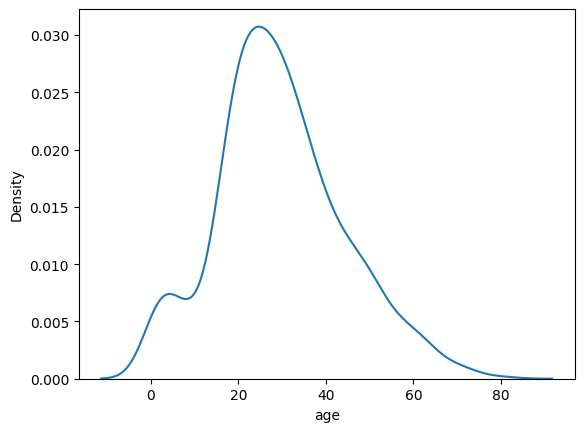

In [26]:
sns.kdeplot(x='age',data=df)

C:\Users\HP\AppData\Local\Temp\ipykernel_22068\3234920688.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


<Axes: xlabel='age', ylabel='Density'>

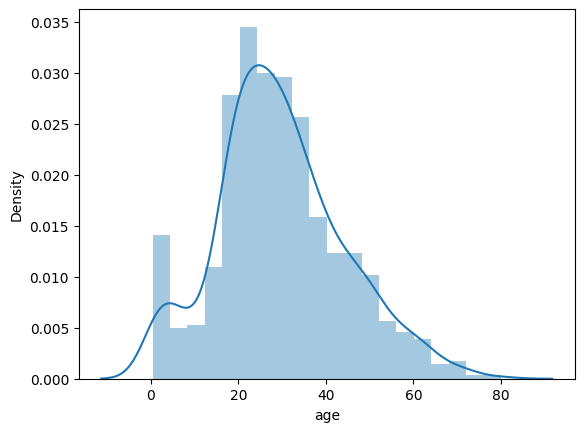

In [27]:
sns.distplot(df['age'])

In [28]:
df.isnull().sum()

age         177
fare          0
survived      0
dtype: int64

In [29]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='mean')

<Axes: xlabel='age', ylabel='Density'>

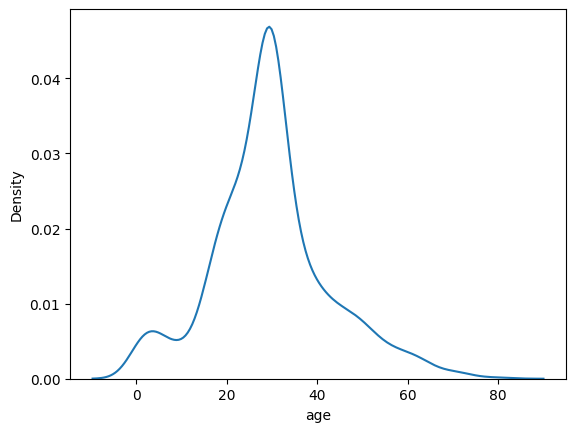

In [30]:
df['age']
df['age'] = si.fit_transform(df[['age']])
sns.kdeplot(x='age',data=df)

C:\Users\HP\AppData\Local\Temp\ipykernel_22068\3234920688.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


<Axes: xlabel='age', ylabel='Density'>

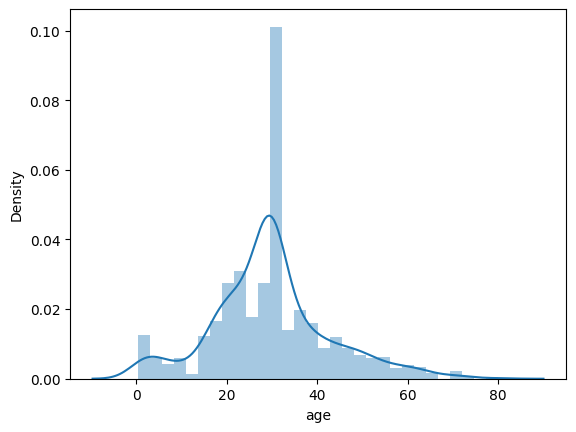

In [31]:
sns.distplot(df['age'])

In [38]:
import matplotlib.pyplot as plt

((array([-3.16416595e+00, -2.89636677e+00, -2.74675222e+00, -2.64114608e+00,
         -2.55870259e+00, -2.49067391e+00, -2.43252738e+00, -2.38160005e+00,
         -2.33618969e+00, -2.29513992e+00, -2.25762808e+00, -2.22304736e+00,
         -2.19093694e+00, -2.16093830e+00, -2.13276686e+00, -2.10619283e+00,
         -2.08102787e+00, -2.05711563e+00, -2.03432484e+00, -2.01254418e+00,
         -1.99167841e+00, -1.97164537e+00, -1.95237369e+00, -1.93380097e+00,
         -1.91587229e+00, -1.89853909e+00, -1.88175821e+00, -1.86549107e+00,
         -1.84970311e+00, -1.83436318e+00, -1.81944313e+00, -1.80491744e+00,
         -1.79076290e+00, -1.77695830e+00, -1.76348425e+00, -1.75032296e+00,
         -1.73745806e+00, -1.72487445e+00, -1.71255819e+00, -1.70049636e+00,
         -1.68867698e+00, -1.67708890e+00, -1.66572174e+00, -1.65456583e+00,
         -1.64361212e+00, -1.63285214e+00, -1.62227795e+00, -1.61188210e+00,
         -1.60165759e+00, -1.59159783e+00, -1.58169661e+00, -1.57194806e+00,

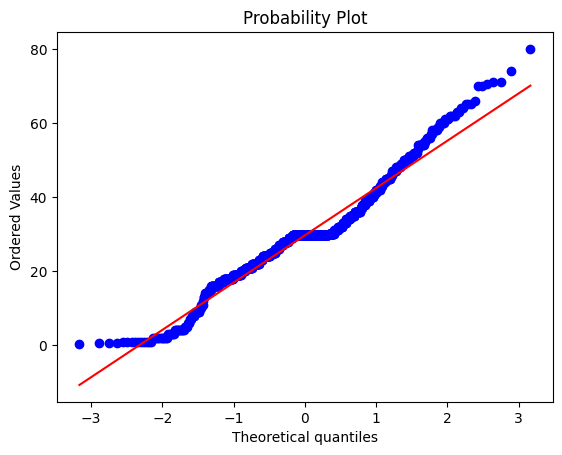

In [33]:
stats.probplot(df['age'],dist='norm',plot=plt)

In [34]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [35]:
ft = FunctionTransformer(func = np.log1p)

((array([-3.16416595e+00, -2.89636677e+00, -2.74675222e+00, -2.64114608e+00,
         -2.55870259e+00, -2.49067391e+00, -2.43252738e+00, -2.38160005e+00,
         -2.33618969e+00, -2.29513992e+00, -2.25762808e+00, -2.22304736e+00,
         -2.19093694e+00, -2.16093830e+00, -2.13276686e+00, -2.10619283e+00,
         -2.08102787e+00, -2.05711563e+00, -2.03432484e+00, -2.01254418e+00,
         -1.99167841e+00, -1.97164537e+00, -1.95237369e+00, -1.93380097e+00,
         -1.91587229e+00, -1.89853909e+00, -1.88175821e+00, -1.86549107e+00,
         -1.84970311e+00, -1.83436318e+00, -1.81944313e+00, -1.80491744e+00,
         -1.79076290e+00, -1.77695830e+00, -1.76348425e+00, -1.75032296e+00,
         -1.73745806e+00, -1.72487445e+00, -1.71255819e+00, -1.70049636e+00,
         -1.68867698e+00, -1.67708890e+00, -1.66572174e+00, -1.65456583e+00,
         -1.64361212e+00, -1.63285214e+00, -1.62227795e+00, -1.61188210e+00,
         -1.60165759e+00, -1.59159783e+00, -1.58169661e+00, -1.57194806e+00,

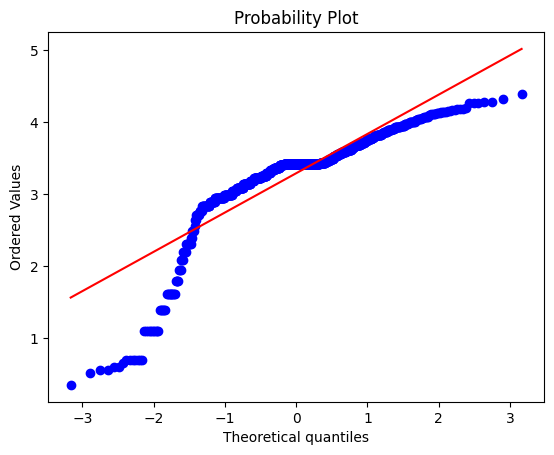

In [43]:
df['age_log'] = ft.fit_transform(df[['age']])
stats.probplot(df['age_log'], dist='norm', plot=plt)

In [52]:
def plot_on_func(fn):
    ft2 = FunctionTransformer(func = fn)
    df['new_age'] = ft2.fit_transform(df[['age']])
    # stats.probplot(df['age'],dist='norm',plot=plt)
    stats.probplot(df['new_age'],dist='norm',plot=plt)

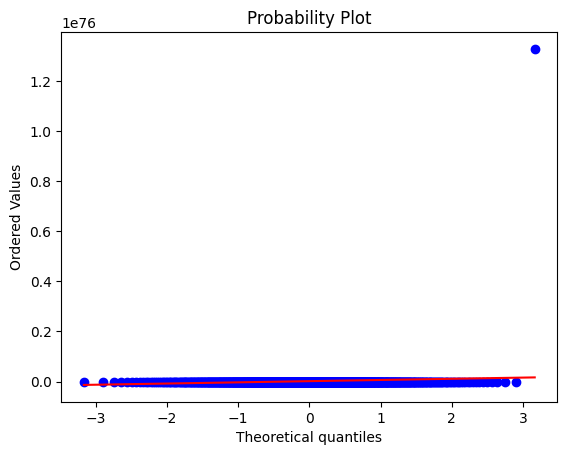

In [67]:
plot_on_func(lambda x : x**(x**1/2))

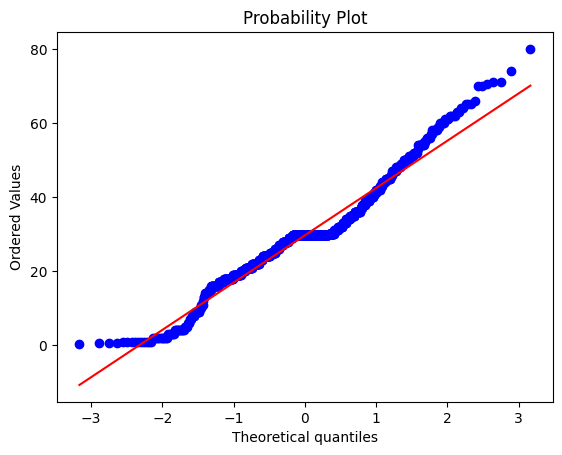

In [68]:
plot_on_func(lambda x: x)

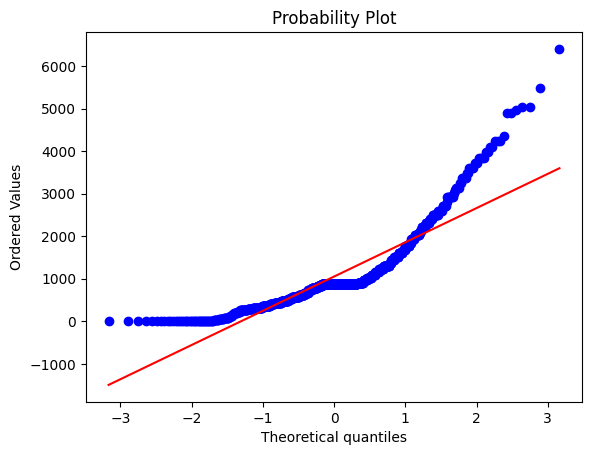

In [82]:
plot_on_func(lambda x: x**2)